# Возможные проблемные ситуации и их решение

## Получение ошибочных данных границ населенного пункта

В ряде случаев онлайн сервис Overpass (возвращающий данные по запросу от OpenStreetMap), неправильно интерпретирует запрос и возвращает не те данные которые требуются пользователю. Например запрос `Новокузнецк, Кемеровская область, Россия` вернет полигон границ не города Новокузнецка, а аэропорта с таким же названием.

Настоятельно рекомендуется после получения, в корректности полученных данных.

,geometry,bbox_west,bbox_south,bbox_east,bbox_north,place_id,osm_type,osm_id,lat,lon,class,type,place_rank,importance,addresstype,name,display_name
0,"POLYGON ((86.85872 53.80025, 86.86369 53.79943...",86.858715,53.796861,86.887795,53.824645,202725781,way,75208218,53.810617,86.867009,aeroway,aerodrome,30,0.457842,aeroway,Novokuznetsk (Spichenkovo) Airport,"Novokuznetsk (Spichenkovo) Airport, Подъезд к ..."


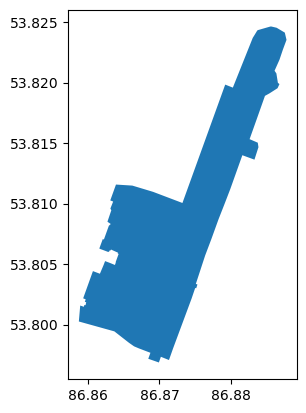

In [4]:
import osmnx as ox

city_name = 'Новокузнецк, Кемеровская область, Россия'
borders = ox.geocode_to_gdf(city_name)
borders.plot()
borders

Проверить корректность данных можно, например, напечатав их. В примере выше видно, что поле `addresstype` содержит значение `aeroway` (аэропорт), в то время как должен содержать `city`.

Исправить запрос можно несколькими способами:

* дополнить запрос уточнением `город`
* написать запрос на английском языке

In [2]:
city_name = 'город Новокузнецк, Кемеровская область, Россия'
borders = ox.geocode_to_gdf(city_name)
borders['addresstype']

0    city
Name: addresstype, dtype: object

In [3]:
city_name = 'Novokuznetsk, Russia'
borders = ox.geocode_to_gdf(city_name)
borders['addresstype']

0    city
Name: addresstype, dtype: object